# Create a contour

This notebook calculates a bathymetry contour and mask, but is applicable to an arbitrary variable, such as sea surface height. There are two different approaches presented in this notebook to select a contour:

**Approach 1**: Extracting the coordinates using `matplotlib`'s `Path` class:
- Use this if you want a quick and dirty contour for masking different regions (e.g. Antarctic continental shelf).
- Assumes the contour you want to select is continuous.
- Gives you the cells closest to the selected contour, they can be deeper or shallower.
- Does not connect all points adjacently, i.e. there are diagonals across the corners (hence this method is not appropriate to calculate cross-contour transport).
  
**Approach 2**: Custom method for selecting and tracing a specific contour:
- Use this method if you want to calculate transport across your contour.
- No cells are deeper than selected contour value (unless manually added which might be necessary).
- Cells on contour are connected adjacently.


For Approach 2, we then create masks that can be used to calculate cross-contour transport. These masks can be multiplied with meridional and zonal transports (which must be on the c-grid) to compute transport across the contour in a particular direction, at each position along the contour. Further details are given in `Cross-contour_transport.ipynb`.

This notebook goes through selecting the 1000 m isobath around Antarctica which we often use to separate the Antarctic continental shelf from the offshore Southern Ocean. We use the OM2-01 grid for approach 1 and the OM3-25km grid for approach 2.

Known locations of the Antarctic 1000 m bathymetry contour for commonly used models:
- OM2-01/PanAnt-01 (same grid):
  `/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_01deg.nc` (Approach 1), `/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz` (Approach 2)
- PanAnt-005: `/g/data/ik11/grids/Antarctic_slope_contour_1000m_MOM6_005deg.nc` (Approach 1)
- OM3-25km: `/g/data/ol01/outputs/access-om3-25km/Antarctic_slope_contours/Antarctic_slope_contour_1000m_OM3_25km.nc` (Approach 2)

Computation times shown used conda environment `analysis3-26.06` on 28 broadwell cpus.

First, we load useful packages:

In [1]:
import pandas as pd
import intake
import dask
import matplotlib.pyplot as plt
import netCDF4 as nc
import xarray as xr
import numpy as np
import cmocean
import cv2 # need to install opencv-python for this, used in approach 2

from dask.distributed import Client

catalog = intake.cat.access_nri

In [2]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 126.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39449,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37677,Total threads: 1
Dashboard: /proxy/33373/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:35189,


## Approach 1

Extracting the coordinates using `matplotlib`'s `Path` class

#### Choose experiment

In [3]:
catalog = intake.cat.access_nri
experiment = '01deg_jra55v13_ryf9091' # the RYF90-91 experiment, ACCESS-OM2-01

#### Load quantity we want a contour of, e.g. bathymetry

In [4]:
ht = catalog[experiment].search(variable="ht", frequency="fx").to_dask().ht

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/intake_esm/source.py:314: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


#### Choose a latitude range 

Make sure the contour fits in the range, but there is not too much extra space. Extra space slows down the computation.

In [5]:
lat_range = slice(-82, -59)

In [6]:
ht = ht.sel(yt_ocean=lat_range)

#### Choose your desired contour value

In [7]:
contour_depth = 1000 # metres

Plot your data (always a good idea `:)`)

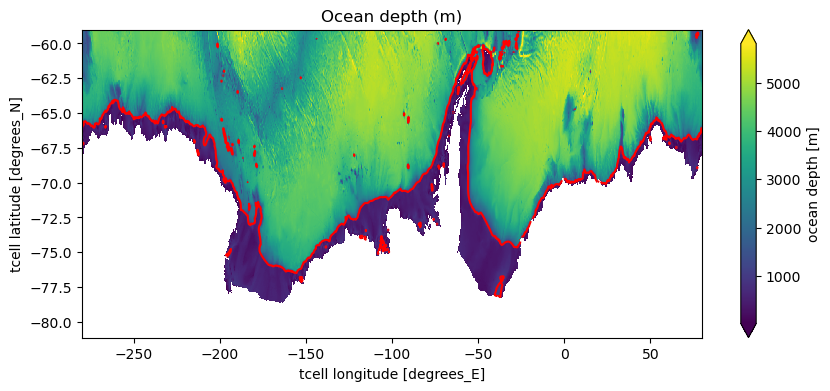

In [8]:
fig = plt.figure(figsize = (10, 4))

ht.plot(extend='both', cbar_kwargs={'label': "ocean depth [m]"})
ht.plot.contour(levels = [contour_depth], colors = 'r', linestyles = '-')
plt.title('Ocean depth (m)');

Fill in land with zeros and load:

In [9]:
ht = ht.fillna(0).load()

Contour is on t-grid (we assume ACCESS-OM2 B-grid transports)

In [10]:
grid_sel = 't'
x_var = ht['xt_ocean']
y_var = ht['yt_ocean']

#### Select the contour 
We need to isolate out the single contour along the slope and get rid of the contours on the little isolated sea mounts and depressions.

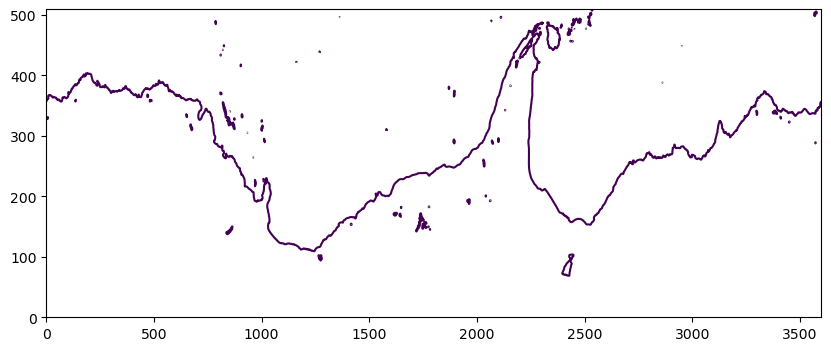

In [11]:
fig = plt.figure(figsize = (10, 4))
sc = plt.contour(ht, levels=[contour_depth])

path_vertices = (sc.get_paths()[0]).vertices
x_vertices = path_vertices[:, 0]
y_vertices = path_vertices[:, 1]

This list of path_vertices includes all of the paths in the above figure. But we want to only select the longest contour. The contours are all stacked in `x_vertices` and `y_vertices`, with the longest contour listed first. We need to find the end of the longest contour and cut `x_vertices`/`y_vertices` at that point.

Along our desired contour, `x_vertices`/`y_vertices` should increase/decrease by max 1, so we can use the location where `diff(x_vertices) > 1` to find the end of our desired contour.

When we call `np.diff`, we wind up with floating point numbers. To get a mask where the difference is greater than 1, we can just turn the result of `np.diff(x_vertices)` back into an array of integers using `.astype(int)` on it - so we can cleanly check if the result is greater than 1.

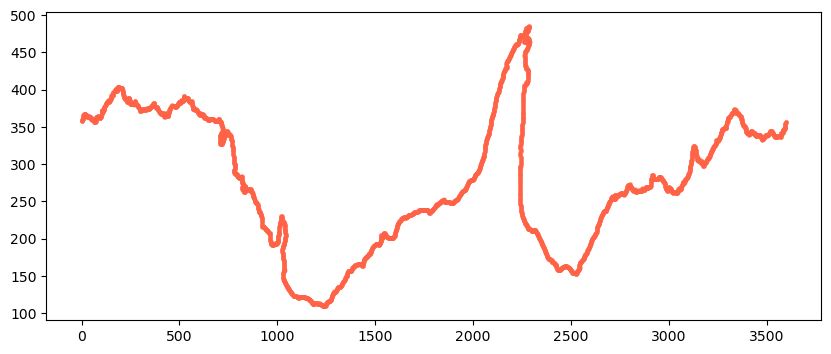

In [12]:
last_contour_index = np.where(np.abs(np.diff(x_vertices).astype(int)) > 1)[0][0]

x_contour = x_vertices[:last_contour_index + 1]
y_contour = y_vertices[:last_contour_index + 1]

# Check desired contour looks right:
fig = plt.figure(figsize = (10, 4))
plt.scatter(x_contour, y_contour, s=5, alpha=0.5, color='tomato');

`x_contour` and `y_contour` are not integers with this updated contour method.
We need to convert them to integers so we can use them as indices for selecting data on the contour.


In [13]:
x_contour = np.round(x_contour).astype(int)
y_contour = np.round(y_contour).astype(int)

# check that the difference between coords of contour never increase by more than 1:
if np.max(np.abs(np.diff(x_contour))) != 1:
    print('help! x_contour increases by more than 1 between coords.')

if np.max(np.abs(np.diff(y_contour))) != 1:
    print('help! y_contour increases by more than 1 between coords.')

#### Processing
Now process these coordinates to make sure there are no double ups.

N.B: It can be tempting to use numpy's `unique` functionality to do this sort of task - be careful, as it won't preserve order! 

In [14]:
# Difference between two neighbouring indices
diff_x_contour = np.diff(x_contour)
diff_y_contour = np.diff(y_contour)

# Get a list with the indices of duplicates
diff_ind = []
for ii in range(len(diff_x_contour)):
    if (diff_x_contour[ii]==0) and (diff_y_contour[ii]==0):
        diff_ind.append(ii)

In [15]:
# Now remove the indices (start from the end so the indices don't shift)
for ii in range(len(diff_ind)):
    index = diff_ind[::-1][ii]
    x_contour = np.delete(x_contour, index)
    y_contour = np.delete(y_contour, index)

In [16]:
ht_contour = np.zeros(len(x_contour))

for ii in range(len(ht_contour)):
    ht_contour[ii] = ht[y_contour[ii], x_contour[ii]]

Due to the discrete grid, the values on our contour are not exactly the same. We check this makes sense -- if this plot is blank, then something has gone wrong.

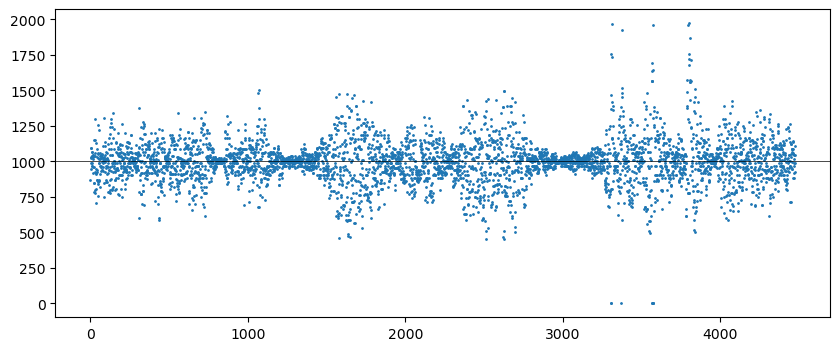

In [17]:
fig = plt.figure(figsize=(10, 4))

plt.plot(ht_contour, 'o', markersize=1)
plt.axhline(contour_depth, color='k', linewidth=0.5);

In [18]:
# Number of grid points on the contour
num_points = len(x_contour)

#### Now we number the points along the contour

In [19]:
# start numbering from 1 not 0:
contour_mask_numbered = np.arange(1, len(x_contour)+1)

In [20]:
contour_mask = xr.zeros_like(ht)

for ii in range(num_points):
    contour_mask[y_contour[ii], x_contour[ii]] = contour_mask_numbered[ii]

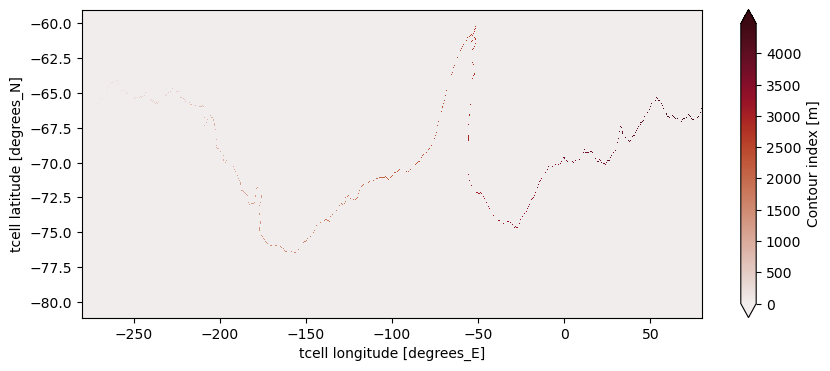

In [21]:
contour_mask.attrs['long_name'] = 'Contour index'
plt.figure(1, figsize=(10, 4))
contour_mask.plot(extend='both', cmap = cmocean.cm.amp);

#### Create mask to separate points above (offshelf) from points below (onshelf) contour

In [22]:
%%time

mask_value = -1000
contour_mask_numbered = contour_mask

# fill in points to north of contour:
contour_masked_above = np.copy(contour_mask_numbered)
contour_masked_above[-1, 0] = mask_value

# from top left:
for ii in range(len(contour_mask.xt_ocean)-1):
    for jj in range(len(contour_mask.yt_ocean))[::-1][:-1]:
        if contour_masked_above[jj, ii] == mask_value:
            if contour_masked_above[jj-1, ii] == 0:
                contour_masked_above[jj-1, ii] = mask_value
            if contour_masked_above[jj, ii+1] == 0:
                contour_masked_above[jj, ii+1] = mask_value

#from top right:
for ii in range(len(contour_mask.xt_ocean))[::-1][:-1]:
    for jj in range(len(contour_mask.yt_ocean))[::-1][:-1]:
        if contour_masked_above[jj, ii] == mask_value:
            if contour_masked_above[jj-1, ii] == 0:
                contour_masked_above[jj-1, ii] = mask_value
            if contour_masked_above[jj, ii-1] == 0:
                contour_masked_above[jj, ii-1] = mask_value

# from bottom right:
for ii in range(len(contour_mask.xt_ocean))[::-1][:-1]:
    for jj in range(len(contour_mask.yt_ocean)-1):
        if contour_masked_above[jj, ii] == mask_value:
            if contour_masked_above[jj+1, ii] == 0:
                contour_masked_above[jj+1, ii] = mask_value
            if contour_masked_above[jj, ii-1] == 0:
                contour_masked_above[jj, ii-1] = mask_value

#from bottom left:
for ii in range(len(contour_mask.xt_ocean)-1):
    for jj in range(len(contour_mask.yt_ocean)-1):
        if contour_masked_above[jj, ii] == mask_value:
            if contour_masked_above[jj+1, ii] == 0:
                contour_masked_above[jj+1, ii] = mask_value
            if contour_masked_above[jj, ii+1] == 0:
                contour_masked_above[jj, ii+1] = mask_value

CPU times: user 7.21 s, sys: 2.87 s, total: 10.1 s
Wall time: 8.09 s


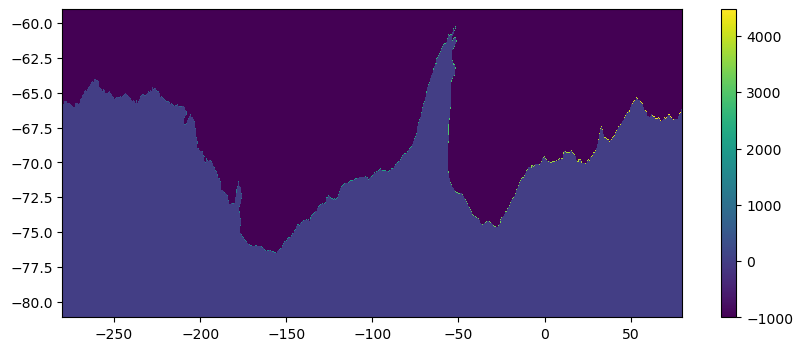

In [23]:
plt.figure(1, figsize=(10, 4))

plt.pcolormesh(contour_mask.xt_ocean, contour_mask.yt_ocean, contour_masked_above)
plt.colorbar()

North of the contour, values have been filled in to be -1000, and it is thus a different colour in the plot.

#### Write as Dataset

In [24]:
# Create dataset

ds_approach1 = xr.Dataset(
    {
        "contour_masked_above": (("yt_ocean", "xt_ocean"), contour_masked_above),
        "contour_mask_numbered": (("yt_ocean", "xt_ocean"), contour_mask_numbered.values),
    },
    coords={
        "xt_ocean": ht.xt_ocean,
        "yt_ocean": ht.yt_ocean,
    },
)

#### Lets use the mask we created to plot surface temperature on the Antarctic contiental shelf.

Load surface temperature

In [25]:
# Define year to open
dates_2086 = '2086.*'

temp = catalog[experiment].search(
    variable='surface_temp', 
    frequency="1mon", 
    start_date=dates_2086
).to_dask()

temp = temp.sel(yt_ocean=lat_range).surface_temp.mean('time')

Create the shelf mask

In [26]:
shelf_mask = ds_approach1.contour_masked_above.where(ds_approach1.contour_masked_above==0, 1)
shelf_mask = shelf_mask.where(shelf_mask==1)

Select shelf 

In [27]:
temp_masked = temp.where(shelf_mask.isnull())

Let's also select the 1000 m contour

In [28]:
slope_contour = ds_approach1.contour_masked_above.where(ds_approach1.contour_masked_above>0)
slope_contour = slope_contour/slope_contour

We can now make the plot

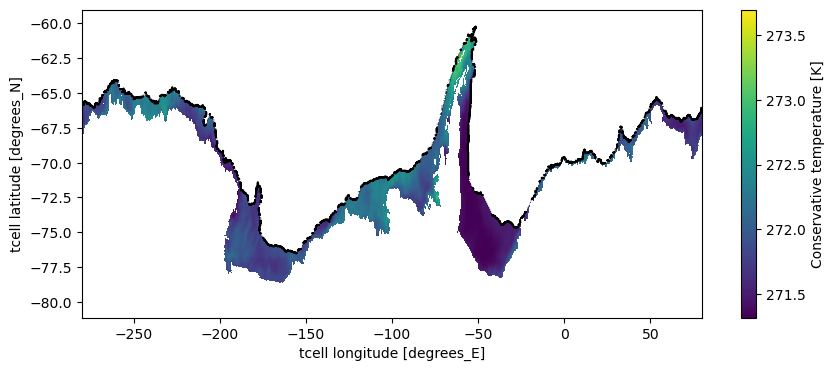

In [29]:
plt.figure(1, figsize=(10, 4))

temp_masked.plot()
slope_contour.fillna(2).plot.contour(levels=[0,1], colors='k', linewidths=1.5);

## Approach 2

Custom method for selecting and tracing a specific depth contour. Use this method if you want to calculate transport across your contour.

Load data from the OM3-25km beta release.

In [30]:
datastore_path = "/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json"

datastore = intake.open_esm_datastore(
    datastore_path,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
    ]
)

#### Choose a latitude range 

Make sure the contour fits in the range, but there is not too much extra space. Extra space slows down the computation.

In [31]:
lat_range = slice(-82, -55)

#### Load quantity we want a contour of, e.g. bathymetry

In [32]:
# Load bathymetry 
var_search = datastore.search(variable="deptho")
ds     = var_search.search(path=var_search.df.path[0]).to_dask() # we only need one file as bathymetry doesn't change
deptho = ds["deptho"].sel(yh=lat_range).load() # select lat_range and load data

Select desired contour value

In [33]:
contour_depth = 1000

Plot the contour. Note there are lots of little isolated sea mounts and depressions, and we need to isolate out the single contour along the slope.

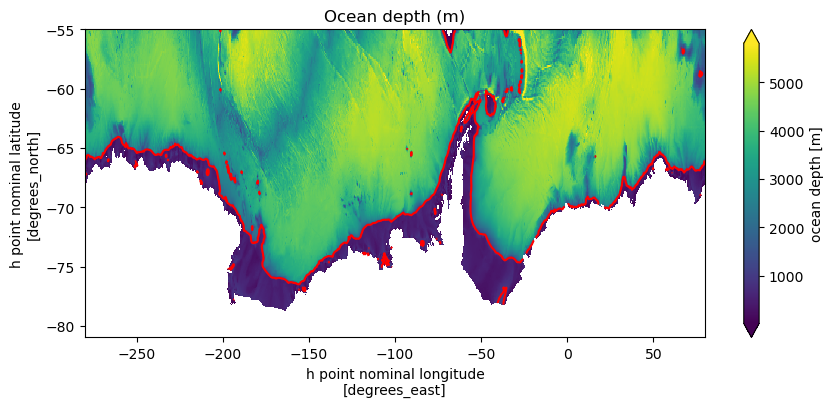

In [34]:
fig = plt.figure(figsize=(10, 4))

deptho.plot(extend='both', cbar_kwargs={'label': "ocean depth [m]"})
deptho.plot.contour(levels=[contour_depth], colors='r', linestyles='-')
plt.title('Ocean depth (m)');

Note if we zoom in, you can also see there are locations near the prime meridian where the 1000 m contour is not continuous (it touches land). We will need to add cells manually next to land below, so it is continuous. 

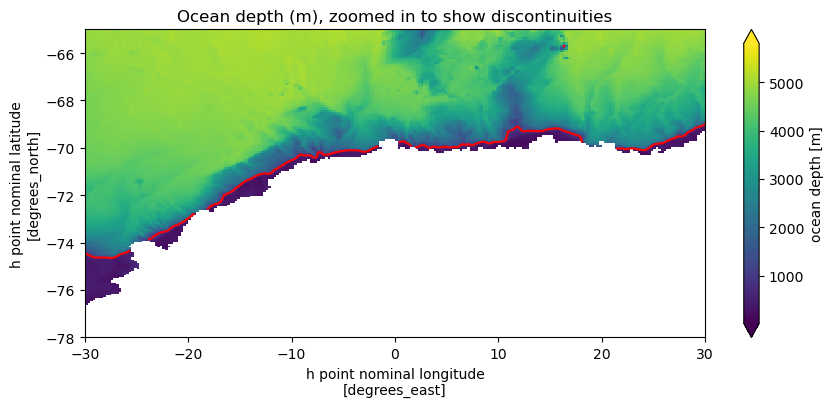

In [35]:
fig = plt.figure(figsize=(10, 4))

deptho.plot(extend='both', cbar_kwargs={'label': "ocean depth [m]"})
deptho.plot.contour(levels=[contour_depth], colors='r', linestyles='-')
plt.title('Ocean depth (m), zoomed in to show discontinuities');
plt.xlim(-30, 30), plt.ylim(-78,-65);

First create a binary mask above and below the desired contour:

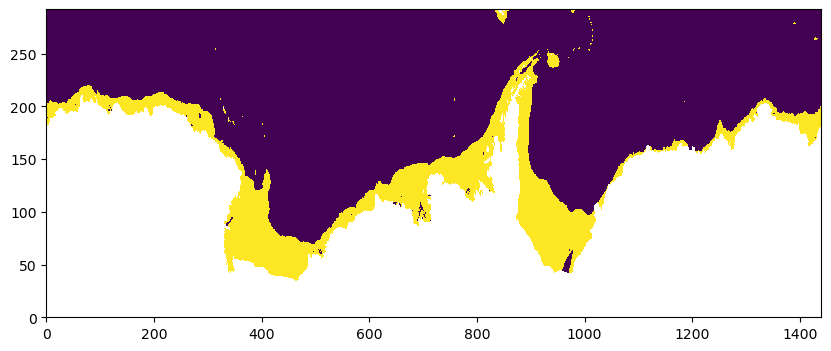

In [36]:
# Temporary mask with 0 where bathymetry is deeper than the contour depth,
# and 1 elsewhere
tmp_mask = np.copy(deptho)
tmp_mask[np.where(deptho>contour_depth)]  = 0 # locations where the bathymetry is deeper than contour_depth
tmp_mask[np.where(deptho<=contour_depth)] = 1 # locations where the bathymetry is shallower or equal to contour_depth

plt.figure(figsize = (10, 4))
plt.pcolormesh(tmp_mask);

Spread the isobath contour so all points are connected adjacently (not just diagonally):

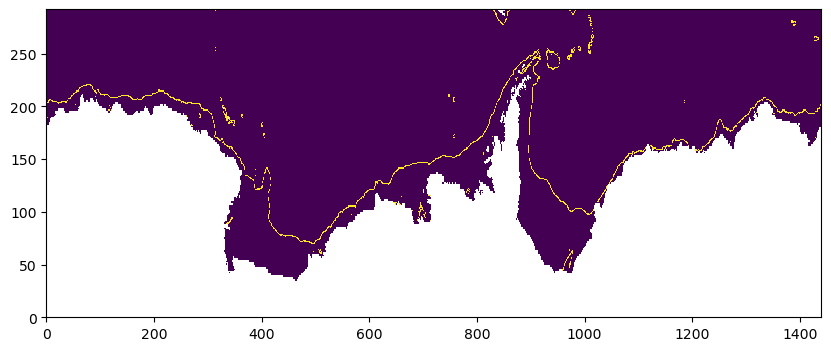

In [37]:
# Spread the ones in tmp_mask to their neighboring pixels (using a 3x3 kernel). 
# This ensures that the contour is connected horizontally and vertically, not just diagonally.
kernel = np.ones((3,3),np.uint8) 

# isolate the edges of the contour -> only the pixels at the boundary of the contour are marked with 1
contour_mask0 = cv2.dilate(tmp_mask,kernel,iterations=1) - tmp_mask 

plt.figure(figsize = (10, 4))
plt.pcolormesh(contour_mask0);

We now need to manually edit some grid cells to ensure a continuous contour and that no loops are connected to the contour. This is specific to the grid and the contour selected! 

Set cells to 0 to remove them from the contour and set to 1 to add cells to contour. 

You need to scan through the whole contour (e.g. from west to east) and visually check for anomalies. Below we give a couple of example of features you want to edit out/in. Note that you only need to edit points on the connected part of the contour. Loops/points that are separated from the contour will be removed in the following step after these manual edits.

Plot `contour_mask0` to check which cells need to be changed:

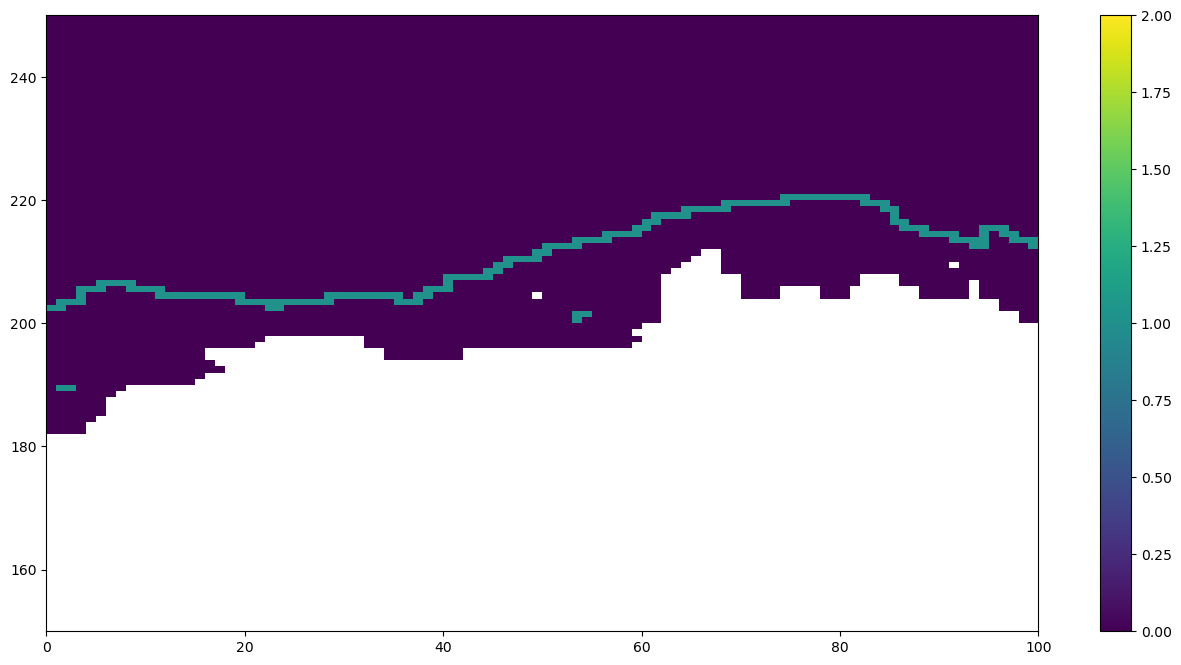

In [38]:
# Check how contour_mask0 looks like 
# - is the contour continuous around Antarctica?
# - are there loops that would not contribute to any cross-slope transport anyway?
# Change the xlim, ylim to zoom into different regions

plt.figure(1,figsize=(16,8))
plt.pcolormesh(contour_mask0)
plt.colorbar()
plt.clim((0,2))

# Scan west to east, start at the west to be systematic:
plt.xlim((0,100))
plt.ylim((150,250));

Here we go through a couple of examples to show you where points may need to be included/excluded:

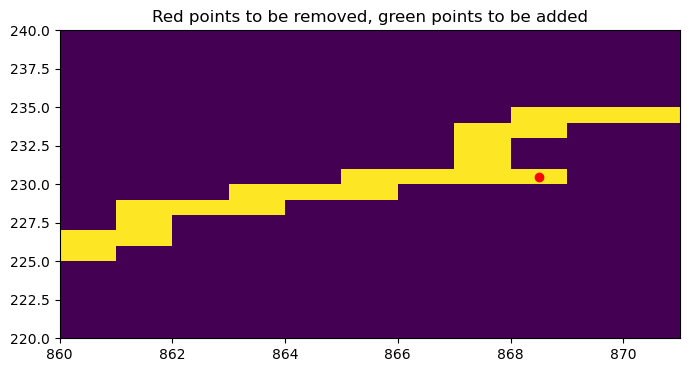

In [39]:
plt.figure(figsize = (8, 4))
plt.pcolormesh(contour_mask0)

plt.xlim(860,871)
plt.ylim(220,240)

# Have a guess of the point you want to remove from the x/y axes, 
# then plot a dot there to double check you guessed it correctly:
x_point = 868
y_point = 230
plt.scatter(x_point + 0.5, y_point + 0.5, color='r')
plt.title('Red points to be removed, green points to be added');

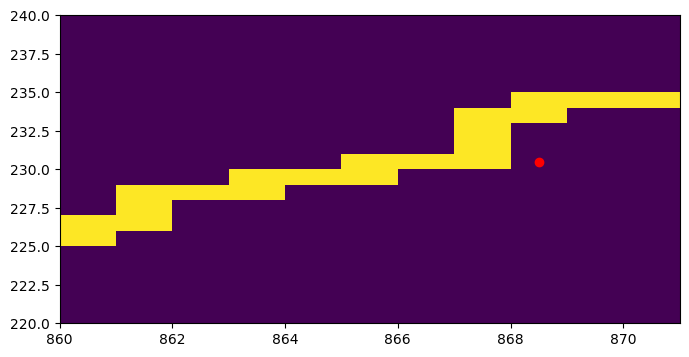

In [40]:
# Remove the point and replot to double check:

# Remove by setting to zero:
contour_mask0[y_point,x_point] = 0

plt.figure(figsize = (8, 4))
plt.pcolormesh(contour_mask0)

plt.xlim(860,871)
plt.ylim(220,240)

plt.scatter(x_point + 0.5, y_point + 0.5, color='r')

# Success, it's gone!

Sometimes you will need to add points if the contour is not continuous (in this case it runs into land), like this:

Text(0.5, 1.0, 'Red points to be removed, green points to be added')

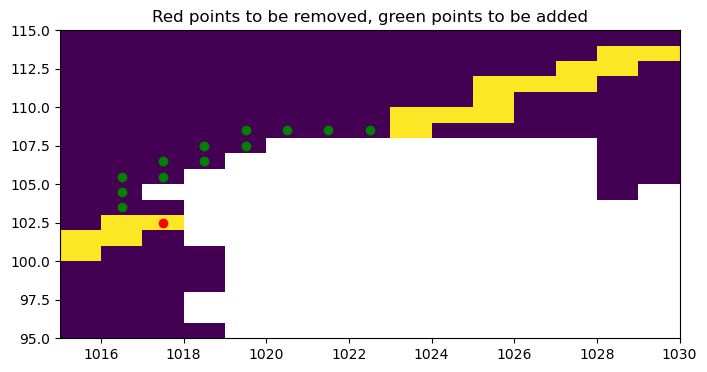

In [41]:
plt.figure(figsize = (8, 4))
plt.pcolormesh(contour_mask0)

plt.xlim(1015,1030)
plt.ylim(95,115)

# Have a guess of the point you want to remove from the x/y axes, 
# then plot a dot there to double check you guessed it correctly:
x_point = 1017
y_point = 102
plt.scatter(x_point + 0.5, y_point + 0.5, color='r')

# In this case we also need to add a bunch of points to the contour:

points_to_add = [
    (103, 1016),
    (104, 1016),
    (105, 1016),
    (105, 1017),
    (106, 1017),
    (106, 1018),
    (107, 1018),
    (107, 1019),
    (108, 1019),
    (108, 1020),
    (108, 1021),
    (108, 1022),
]
points_offset = [(x + 0.5, y + 0.5) for x, y in points_to_add]
y, x = zip(*points_offset)
plt.scatter(x, y, color='g')
plt.title('Red points to be removed, green points to be added')

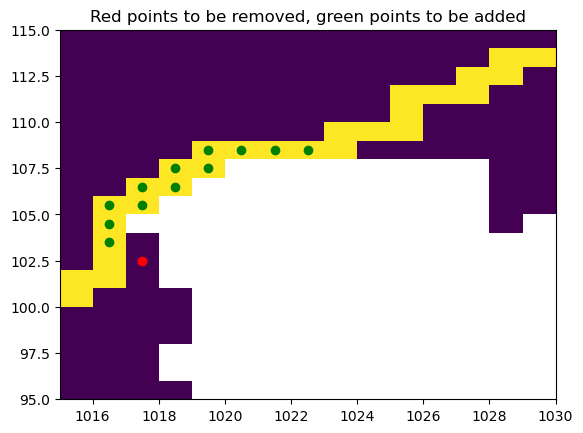

In [42]:
# Remove/add points and replot to double check:

# careful with indexing, e.g. 103:106 captures y-indices 103, 104, 105:
# adding:
contour_mask0[103:106,1016] = 1
contour_mask0[105:107,1017] = 1
contour_mask0[106:108,1018] = 1
contour_mask0[107:109,1019] = 1
contour_mask0[108,1019:1023] = 1
# removing:
contour_mask0[102,1017] = 0

# replot:
plt.pcolormesh(contour_mask0)
plt.xlim(1015,1030)
plt.ylim(95,115)
plt.scatter(x_point + 0.5, y_point + 0.5, color='r')
plt.scatter(x, y, color='g')
plt.title('Red points to be removed, green points to be added');

# Success!

This is the full list of cells that needed editing for the OM3-25km grid with contour_depth = 1000:

In [43]:
# Below is true for the OM3-25km grid with contour_depth = 1000

# These ones are commented, because we already made these changes in the cells above:
'''contour_mask0[230,868] = 0
contour_mask0[102,1017] = 0
contour_mask0[103:106,1016] = 1
contour_mask0[105:107,1017] = 1
contour_mask0[106:108,1018] = 1
contour_mask0[107:109,1019] = 1
contour_mask0[108,1019:1023] = 1'''

contour_mask0[247:254,914:921] = 0
contour_mask0[253,913] = 0
contour_mask0[249,909] = 0
contour_mask0[245:249,908] = 0
contour_mask0[244:249,916] = 0
contour_mask0[225:230,914] = 0
contour_mask0[125,1042:1044] = 1
contour_mask0[126,1043:1046] = 1

contour_mask0[161:163,1113] = 1
contour_mask0[162,1113:1115] = 1
contour_mask0[162:165,1115] = 1
contour_mask0[164,1115:1120] = 1
contour_mask0[162:165,1120] = 1
contour_mask0[162,1121] = 1
contour_mask0[160,1127] = 1
contour_mask0[159,1128] = 0

contour_mask0[160:163,1194] = 1
contour_mask0[160,1194:1199] = 1
contour_mask0[160:163,1199] = 1
contour_mask0[162,1199:1207] = 1
contour_mask0[160:163,1206] = 1

contour_mask0[123:125,401] = 0

Select out only the contour we want: We can now finally trace the connected contour from our starting point to the right edge of the grid, marking each point along the contour with a unique label (`count`). The algorithm checks the 4-connected neighbours (east, west, south, north) of the current point and checks each neighbour to see if it is (i) within the grid bounds and (ii) part of the contour and unvisited. The first valid neighbour found is selected as the next point (`new_loc`). If no valid neighbours are found, the contour has reached a dead end, and the loop terminates - if this happens before we reach the eastern boundary we need to go back and amend `contour_mask0`.

Select a starting point for tracing the contour along the western edge of the domain:

In [44]:
# start at western edge of domain, at y point closest to correct depth contour:
# pick most northerly contour:
contour_lat_index_start = np.where(contour_mask0[:,0]>0)[0][-1]

# Depending on your contour/domain, you may want to pick most southerly contour: 
# contour_lat_index_start = np.where(contour_mask0[:,0]>0)[0][0]

# starting point is marked with 1 in contour_mask, which can then be used as a seed for further contour tracing or region-growing algorithms
contour_mask = np.zeros_like(deptho)
contour_mask[contour_lat_index_start,0] = 1

Plot to make sure contour_lat_index_start (yellow dot) is on the correct contour:

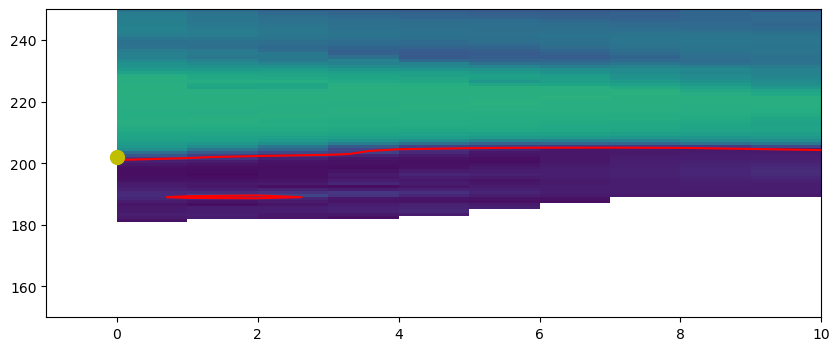

In [45]:
plt.figure(figsize = (10, 4))
plt.pcolormesh(deptho)
plt.contour(deptho,[contour_depth],colors='r')
plt.xlim((-1,10))
plt.ylim((150,250))
plt.plot(0,contour_lat_index_start,'yo',markersize=10)

In [46]:
# set up indices
last_index_i = 0
last_index_j = contour_lat_index_start
count = 1  # start labeling from 1

# mark starting point
contour_mask[last_index_j, last_index_i] = count
contour_mask0[last_index_j, last_index_i] = 0  # mark as visited

# loop until the right edge or dead end
while last_index_i < deptho.shape[1]-1:
    
    # define neighbours
    if last_index_i == 0:
        # first step: don't go backwards
        neighbours = [
            (last_index_j, last_index_i+1),   # east
            (last_index_j+1, last_index_i),   # south
            (last_index_j-1, last_index_i)    # north
        ]
    else:
        # after first step: include west
        neighbours = [
            (last_index_j, last_index_i+1),   # east
            (last_index_j, last_index_i-1),   # west
            (last_index_j+1, last_index_i),   # south
            (last_index_j-1, last_index_i)    # north
        ]

    # find valid neighbours
    new_loc = None
    for nj, ni in neighbours:
        if 0 <= nj < contour_mask0.shape[0] and 0 <= ni < contour_mask0.shape[1]:
            if contour_mask0[nj, ni] == 1:  # unvisited contour
                new_loc = (nj, ni)
                break

    if new_loc is None:
        # dead end → stop
        print("Dead end reached at step", count)
        break
    else:
        # move to next point
        last_index_j, last_index_i = new_loc
        count += 1
        contour_mask[last_index_j, last_index_i] = count
        contour_mask0[last_index_j, last_index_i] = 0  # mark visited

We can now check what `contour_mask` looks like - is it continuous around Antarctica? Are there still any loops or duplicate cells that are not needed?

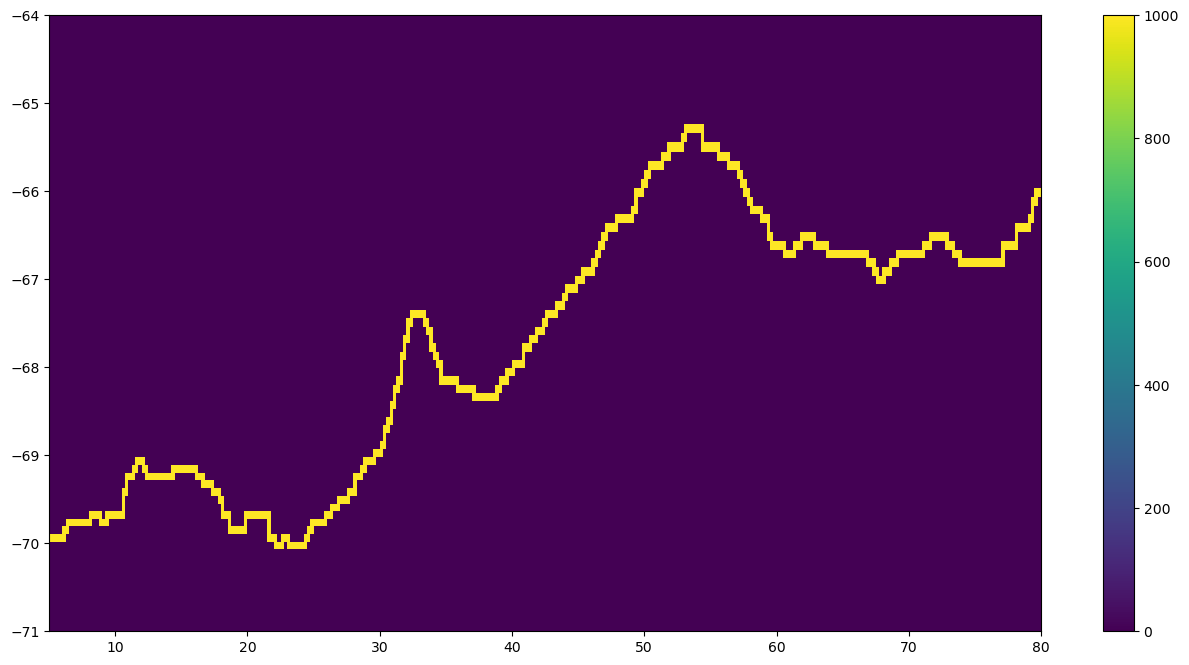

In [47]:
plt.figure(1,figsize=(16,8))
plt.pcolormesh(deptho.xh,deptho.yh,contour_mask)
plt.colorbar()
plt.clim((0,1000))
plt.xlim((5,80))      # adjust xlim and ylim to zoom in and tracer the contour
plt.ylim((-71,-64));

Looking good! We can now proceed as for approach 1 and...

#### Create mask to separate points above (offshelf) from points below (onshelf) contour

This is needed so that the direction of the contour can be determined.

In [48]:
contour_mask_numbered = contour_mask

# fill in points to north of contour:
contour_masked_above = np.copy(contour_mask_numbered)
contour_masked_above[-1,0] = -100

# from top left:
for ii in range(len(deptho.xh)-1):
    for jj in range(len(deptho.yh))[::-1][:-1]:
        if contour_masked_above[jj,ii] == -100:
            if contour_masked_above[jj-1,ii] == 0:
                contour_masked_above[jj-1,ii] = -100
            if contour_masked_above[jj,ii+1] == 0:
                contour_masked_above[jj,ii+1] = -100
            if contour_masked_above[jj-1,ii+1] == 0:
                contour_masked_above[jj-1,ii+1] = -100
# from top right:
for ii in range(len(deptho.xh))[::-1][:-1]:
    for jj in range(len(deptho.yh))[::-1][:-1]:
        if contour_masked_above[jj,ii] == -100:
            if contour_masked_above[jj-1,ii] == 0:
                contour_masked_above[jj-1,ii] = -100
            if contour_masked_above[jj,ii-1] == 0:
                contour_masked_above[jj,ii-1] = -100
            if contour_masked_above[jj-1,ii-1] == 0:
                contour_masked_above[jj-1,ii-1] = -100
# from bottom right:
for ii in range(len(deptho.xh))[::-1][:-1]:
    for jj in range(len(deptho.yh)-1):
        if contour_masked_above[jj,ii] == -100:
            if contour_masked_above[jj+1,ii] == 0:
                contour_masked_above[jj+1,ii] = -100
            if contour_masked_above[jj,ii-1] == 0:
                contour_masked_above[jj,ii-1] = -100
            if contour_masked_above[jj+1,ii-1] == 0:
                contour_masked_above[jj+1,ii-1] = -100
# from bottom left:
for ii in range(len(deptho.xh)-1):
    for jj in range(len(deptho.yh)-1):
        if contour_masked_above[jj,ii] == -100:
            if contour_masked_above[jj+1,ii] == 0:
                contour_masked_above[jj+1,ii] = -100
            if contour_masked_above[jj,ii+1] == 0:
                contour_masked_above[jj,ii+1] = -100
            if contour_masked_above[jj+1,ii+1] == 0:
                contour_masked_above[jj+1,ii+1] = -100


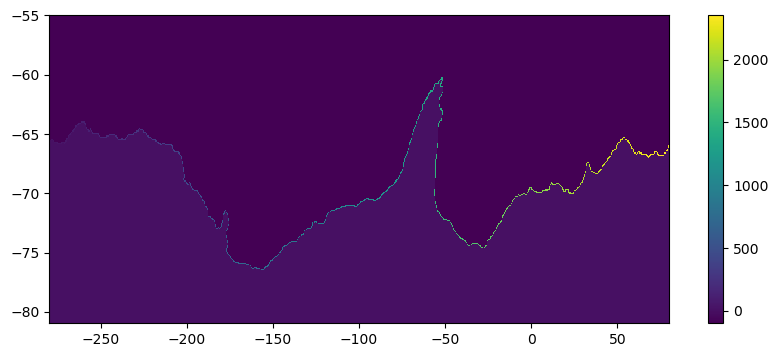

In [49]:
plt.figure(1, figsize=(10, 4))

plt.pcolormesh(deptho.xh,deptho.yh, contour_masked_above)
plt.colorbar()

North of the contour, values have been filled in to be -100, and it is thus a different colour in the plot.

#### Direction of cross-contour transport
Now we can use the mask to determine whether the transport across the contour should be north, east, south or west (the grid is made of discrete square(ish) shaped cells). This is done by looping through the contour points and determining in which directions there are zeros (i.e. below contour) and -100 (i.e. above contour). This means the orientation of the contour can be determined. This is saved as `mask_x_transport`, which has -1 and +1 in a 2D (x and y) array where the contour has eastward transport, and `mask_y_transport` which as -1 and +1 for coordinates with northward transport. All other positions in the array are 0. This means that multiplying the northward transport `ty_trans` by the `mask_y_transport` gives all the northward transport across the contour, and zeros everywhere else (e.g. where contour goes upwards and cross-contour transport is thus eastward).

**Note**: This can also be done for approach 1; the saved files mentioned in the preamble contain that information. However, cross-contour transport is only accurate when based on a contour selected following approach 2.

#### Create masks for x and y transport calculations (i.e. determine if positive u and v will be into or out of contour)

In [106]:
# separate out points on isobath that will correspond to zonal or meridional transport
# across contour (i.e. depending on localshape of contour):

# make masks to multiply x and y transports at correct places:
mask_x_transport = np.zeros_like(contour_mask_numbered)
mask_y_transport = np.zeros_like(contour_mask_numbered)
mask_y_transport_numbered = np.zeros_like(contour_mask_numbered)
mask_x_transport_numbered = np.zeros_like(contour_mask_numbered)
# make halos:
contour_masked_above_halo = np.zeros((contour_masked_above.shape[0],
    contour_masked_above.shape[1]+2))
contour_masked_above_halo[:,0] = contour_masked_above[:,-1]
contour_masked_above_halo[:,1:-1] = contour_masked_above
contour_masked_above_halo[:,-1] = contour_masked_above[:,0]

new_number_count = 1
for mask_loc in range(1,int(np.max(contour_mask_numbered))+1):
    #if mask_loc%100 == 0:
    #    print('mask for x/y transport at point '+str(mask_loc))
    index_i = np.where(contour_mask_numbered==mask_loc)[1]
    index_j = np.where(contour_mask_numbered==mask_loc)[0]
    # if point above is towards Antarctica and point below is away from Antarctica:
    # take transport grid point to north of t grid:
    if (contour_masked_above[index_j+1,index_i]==0) and (contour_masked_above[index_j-1,index_i]!=0):
        mask_y_transport[index_j,index_i] = -1
        # important to do 
        mask_y_transport_numbered[index_j,index_i] = new_number_count
        new_number_count += 1
    # if point below is towards Antarctica and point above is away from Antarctica:
    # take transport grid point to south of t grid:
    elif (contour_masked_above[index_j-1,index_i]==0) and (contour_masked_above[index_j+1,index_i]!=0):
        mask_y_transport[index_j-1,index_i] = 1
        mask_y_transport_numbered[index_j-1,index_i] = new_number_count
        new_number_count += 1
    # if point to right is towards Antarctica and point to left is away from Antarctica:
    # zonal indices increased by 1 due to halos
    # take transport grid point on right of t grid:
    if (contour_masked_above_halo[index_j,index_i+2]==0) and (contour_masked_above_halo[index_j,index_i]!=0):
        mask_x_transport[index_j,index_i] = -1
        mask_x_transport_numbered[index_j,index_i] = new_number_count
        new_number_count += 1
    # if point to left is towards Antarctica and point to right is away from Antarctica:
    # take transport grid point on left of t grid:
    elif (contour_masked_above_halo[index_j,index_i]==0) and (contour_masked_above_halo[index_j,index_i+2]!=0):
        mask_x_transport[index_j,index_i-1] = 1
        mask_x_transport_numbered[index_j,index_i-1] = new_number_count
        new_number_count += 1

#### Write as dataset

Here we convert the contour masks to a dataset (which could be saved and reloaded). We need to ensure the lat / lon coordinates correspond to the actual data location.

Hint 1: for MOM5 (e.g. OM2-01) this would be:
- The y masks are used for `ty_trans`, so like `vhrho` this should have dimensions (`yu_ocean`, `xt_ocean`).
- The x masks are used for `tx_trans`, so like `uhrho` this should have dimensions (`yt_ocean`, `xu_ocean`).

Hint 2: You can set the actual name to always be simply latitude/longitude irrespective of the variable to make concatenation of transports in both direction and sorting possible. An example is given in [Cross_contour_transport.ipynb](https://github.com/COSIMA/cosima-recipes/blob/main/03-Advanced-Recipes/Cross-contour_transport.ipynb). 

In [107]:
# Load umo and vmo to get correct coordinate information (info might also be in some grid file?)
umo = datastore.search(variable='umo').to_dask().umo.sel(yh=slice(-82,-55))
vmo = datastore.search(variable='vmo').to_dask().vmo.sel(yq=slice(-82,-54.9))

In [109]:
# Create dataset
ds_approach2 = xr.Dataset(
    {
        "mask_x_transport": (("yh", "xq"), mask_x_transport),
        "mask_y_transport": (("yq", "xh"), mask_y_transport),
        "mask_x_transport_numbered": (("yh", "xq"), mask_x_transport_numbered),
        "mask_y_transport_numbered": (("yq", "xh"), mask_y_transport_numbered),
        "contour_masked_above": (("yh", "xh"), contour_masked_above),
        "contour_mask_numbered": (("yh", "xh"), contour_mask_numbered),
    },
    coords={
        "xh": deptho.xh,
        "yh": deptho.yh,
        "xq": umo.xq,
        "yq": vmo.yq,
    },
)

And plot just to confirm that we didn't mess up anything.

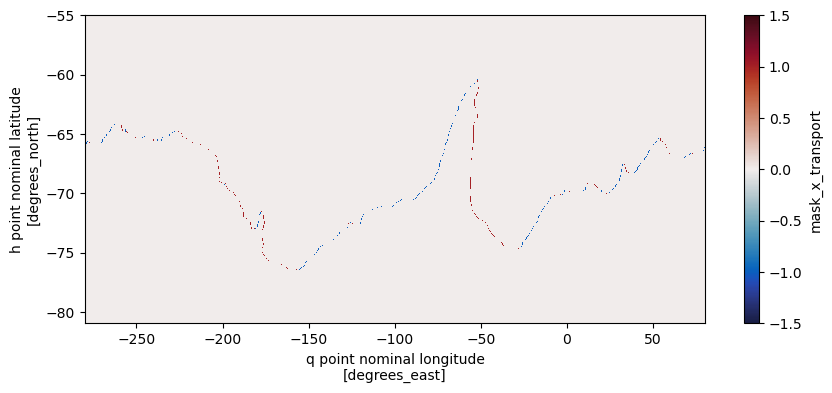

In [51]:
plt.figure(1, figsize=(10, 4))

ds_approach2.mask_x_transport.plot(cmap=cmocean.cm.balance, vmin=-1.5, vmax=1.5);

(-75.0, -71.0)

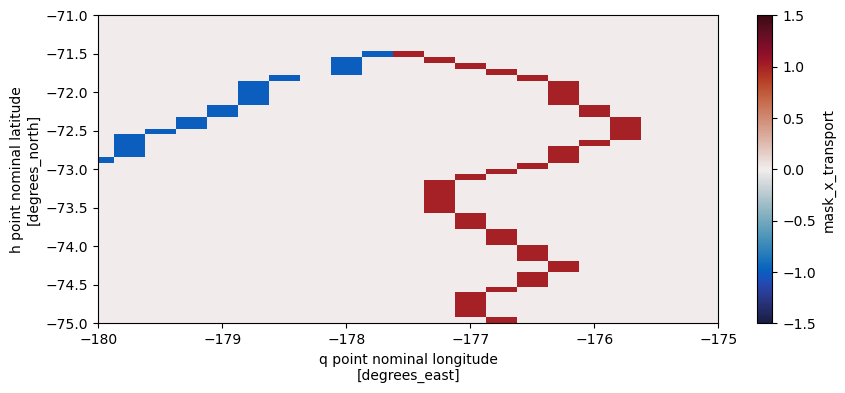

In [110]:
# test:

plt.figure(1, figsize=(10, 4))
ds_approach2.mask_x_transport.plot(cmap=cmocean.cm.balance, vmin=-1.5, vmax=1.5);
plt.xlim(-180,-175)
plt.ylim(-75,-71)

(-75.0, -71.0)

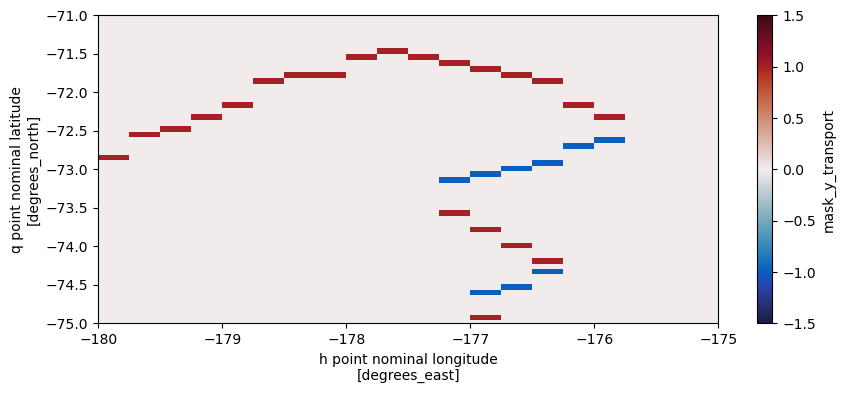

In [112]:
# test:

plt.figure(1, figsize=(10, 4))
ds_approach2.mask_y_transport.plot(cmap=cmocean.cm.balance, vmin=-1.5, vmax=1.5);
plt.xlim(-180,-175)
plt.ylim(-75,-71)